# Códigos usados para responder las preguntas de control

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Pregunta número 4

In [ ]:
# Parametros del problema
n = 16  # tamano de muestra
x_bar = 24  # media muestral
s = 4  # desviacion estandar muestral
confianza = 0.95
alpha = 1 - confianza

# Grados de libertad
gl = n - 1

# Valor critico t
t_critico = stats.t.ppf(1 - alpha/2, gl)
print(f"Valor critico t (95%, gl={gl}): {t_critico:.4f}")
 # Error estandar
error_estandar = s / np.sqrt(n)
print(f"Error estandar: {error_estandar:.4f}")

# Intervalo de confianza
limite_inferior = x_bar - t_critico * error_estandar
limite_superior = x_bar + t_critico * error_estandar
print(f"\nIntervalo de confianza del 95%:")
print(f"[{limite_inferior:.2f}, {limite_superior:.2f}] ")


Valor critico t (95%, gl=15): 2.1314
Error estandar: 1.0000

Intervalo de confianza del 95%:
[21.87, 26.13] 


# Pregunta número 7

In [ ]:
# Parámetros del problema de las baterías
n = 30               # Tamaño de muestra
x_bar = 485          # Media muestral obtenida
s = 50               # Desviación estándar
mu_nominal = 500     # Afirmación del fabricante
confianza = 0.95     # Ya que el nivel de significancia alfa es 0.05
alpha = 1 - confianza

# Intervalo de confianza del 95%
gl = n - 1
t_critico = stats.t.ppf(1 - alpha/2, gl)
error_estandar = s / np.sqrt(n)

li = x_bar - t_critico * error_estandar
ls = x_bar + t_critico * error_estandar

print(f"Intervalo de confianza del 95%: [{li:.2f}, {ls:.2f}] horas")
print(f"Afirmación del fabricante: {mu_nominal} horas")

if li <= mu_nominal <= ls:
  print("\nConclusión: NO hay evidencia para rechazar la afirmación del fabricante (el valor 500 está dentro del IC).")
else:
  print("\nConclusión: SÍ hay evidencia para rechazar la afirmación del fabricante (el valor 500 NO está dentro del IC).")

Intervalo de confianza del 95%: [466.33, 503.67] horas
Afirmación del fabricante: 500 horas

Conclusión: NO hay evidencia para rechazar la afirmación del fabricante (el valor 500 está dentro del IC).


# Pregunta número 2

Media de X̄: 50
Error estándar de X̄: 1.6667
Estadístico Z: 1.20
P(X̄ > 52): 0.1151


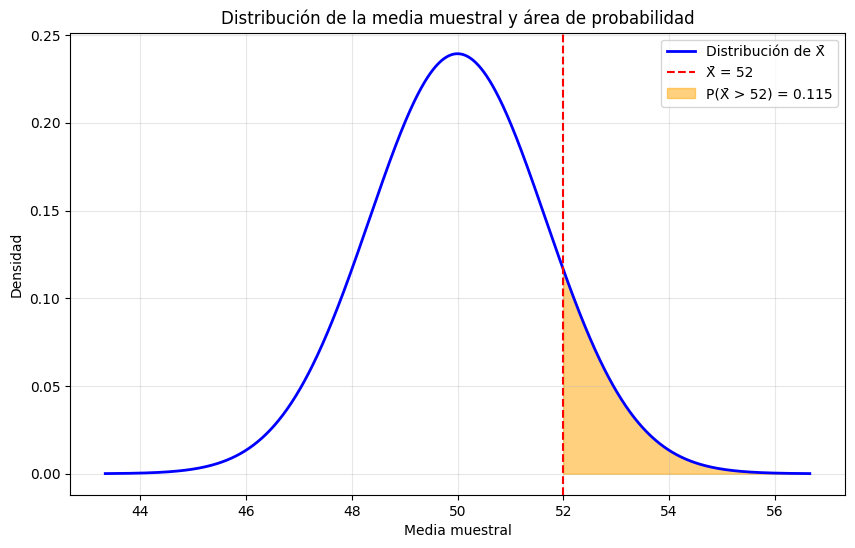

In [ ]:
# Parámetros poblacionales
mu = 50       # media poblacional
sigma = 10    # desviación estándar
n = 36        # tamaño de muestra

# Distribución de la media muestral
mu_xbar = mu
sigma_xbar = sigma / np.sqrt(n)
print(f"Media de X̄: {mu_xbar}")
print(f"Error estándar de X̄: {sigma_xbar:.4f}")

# Probabilidad P(X̄ > 52)
x_val = 52
z = (x_val - mu_xbar) / sigma_xbar
p_val = 1 - stats.norm.cdf(z)
print(f"Estadístico Z: {z:.2f}")
print(f"P(X̄ > 52): {p_val:.4f}")

# Preparación para la graficación
x = np.linspace(mu_xbar - 4*sigma_xbar, mu_xbar + 4*sigma_xbar, 1000)
y = stats.norm.pdf(x, mu_xbar, sigma_xbar)

# Colocación de leyenda
plt.figure(figsize=(10,6))
plt.plot(x, y, 'b-', linewidth=2, label='Distribución de X̄')
plt.axvline(x_val, color='red', linestyle='--', label=f'X̄ = {x_val}')

# Área sombreada a la derecha de 52
x_fill = np.linspace(x_val, mu_xbar + 4*sigma_xbar, 500)
y_fill = stats.norm.pdf(x_fill, mu_xbar, sigma_xbar)
plt.fill_between(x_fill, y_fill, color='orange', alpha=0.5, label=f'P(X̄ > {x_val}) = {p_val:.3f}')

plt.title("Distribución de la media muestral y área de probabilidad")
plt.xlabel("Media muestral")
plt.ylabel("Densidad")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# Pregunta Número 5

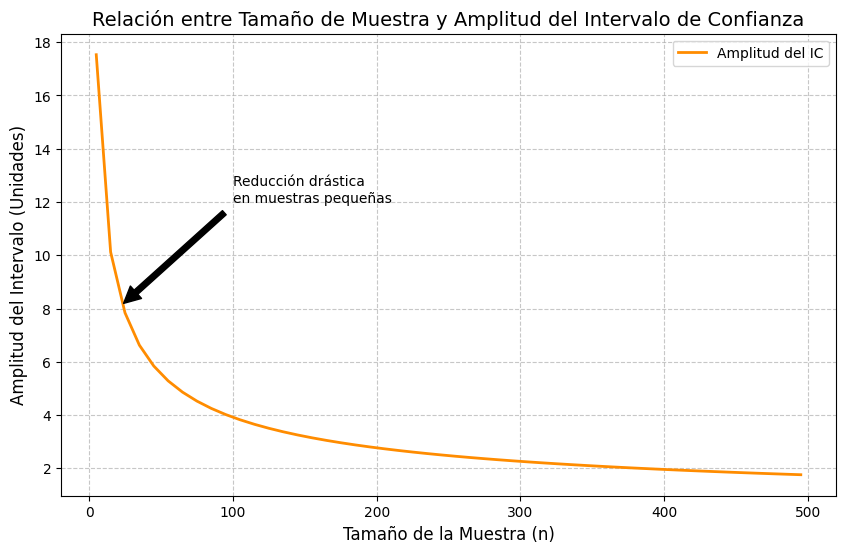

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 1. Parámetros de simulación
sigma = 10           # Desviación estándar poblacional conocida
confianza = 0.95     # Nivel de confianza (95%)
z_critico = stats.norm.ppf(1 - (1 - confianza) / 2)

# 2. Diferentes tamaños de muestra para comparar (de 5 a 500)
tamanos_muestra = np.arange(5, 501, 10)

# 3. Calcular la amplitud del intervalo para cada tamaño de muestra
# Fórmula de amplitud: 2 * Margen de Error = 2 * (z * sigma / sqrt(n))
amplitudes = [2 * (z_critico * sigma / np.sqrt(n)) for n in tamanos_muestra]

# 4. Visualización de la relación
plt.figure(figsize=(10, 6))
plt.plot(tamanos_muestra, amplitudes, color='darkorange', linewidth=2, label='Amplitud del IC')

# Estética de la gráfica
plt.title('Relación entre Tamaño de Muestra y Amplitud del Intervalo de Confianza', fontsize=14)
plt.xlabel('Tamaño de la Muestra (n)', fontsize=12)
plt.ylabel('Amplitud del Intervalo (Unidades)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Anotación para resaltar la caída rápida inicial
plt.annotate('Reducción drástica\nen muestras pequeñas', xy=(20, 8), xytext=(100, 12),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()